# Чтение аудиофайлов

In [ ]:
import numpy as np
from scipy.io.wavfile import read
import matplotlib.pyplot as plt

## Загрузка данных из аудиофайла

In [ ]:
note_A = 'sounds of notes/zvuk-notyi-lya.wav'
frequency, data = read(note_A)
frequency #частота дискретизации

44100

In [ ]:
data.shape

(22071, 2)

In [ ]:
type(data)

numpy.ndarray

Импортируем данные звука ноты Ля, определяем частоту дискретизации, определяем количество аудиоканалов и проверяем тип данных (стерео/моно).
Функция read  возвращает чатоту дискретизации frequency и аудиоданные data.

In [ ]:
data

array([[  20, -616],
       [  18, -785],
       [  41, -796],
       ...,
       [ -90,  -17],
       [-139,   30],
       [-129,   23]], dtype=int16)

## Чтение данных

**Считываем данные с левого и правого канала:**

In [ ]:
left_channel = data[:,0]
left_channel

array([  20,   18,   41, ...,  -90, -139, -129], dtype=int16)

In [ ]:
right_channel = data[:,1]
right_channel

array([-616, -785, -796, ...,  -17,   30,   23], dtype=int16)

**Создаем вектор времени для корректного определения длины данных:**

In [ ]:
timeline = np.arange(right_channel.size)*(1/frequency)

## Построение графика

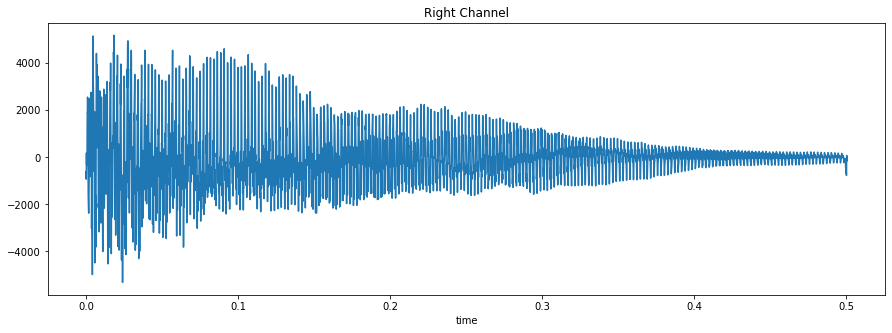

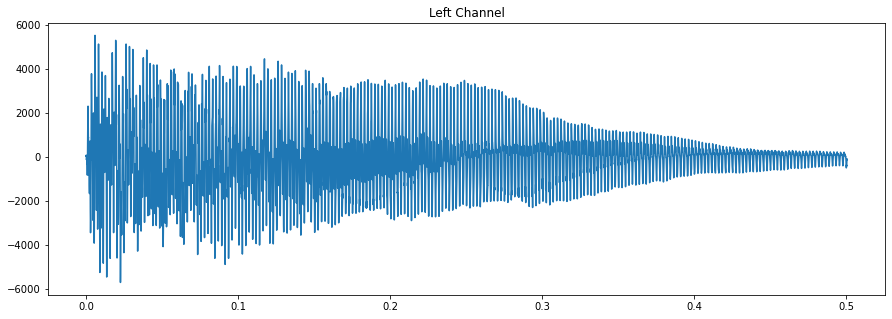

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Right Channel')
plt.xlabel('time')
plt.plot(timeline, right_channel)

plt.figure(figsize=(15,5))
plt.title('Left Channel')
plt.plot(timeline, left_channel)

**Проверка другого файла**

Мелодия сыгранная на фортепиано длиной 10 сек.

In [ ]:
fp = 'sounds/fortepiano_1.wav'
fq, data = read(fp)
fq

44100

In [ ]:
data.shape

(460271, 2)

In [ ]:
type(data)

numpy.ndarray

In [ ]:
left = data[:,0]
right = data[:,1]

time = np.arange(right.size)*(1/fq)
time_len = right.size / fq
time_len

10.436984126984127

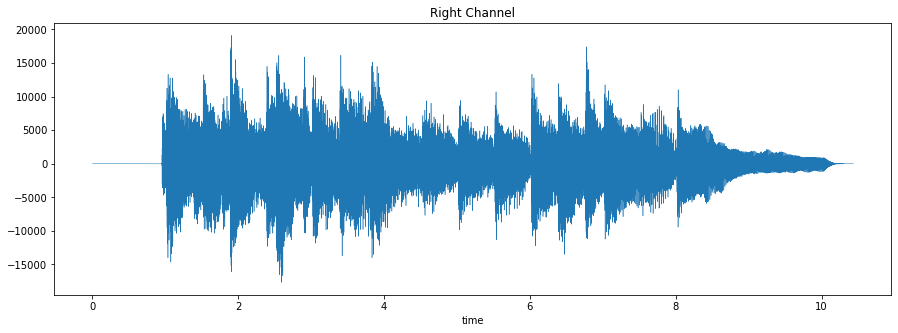

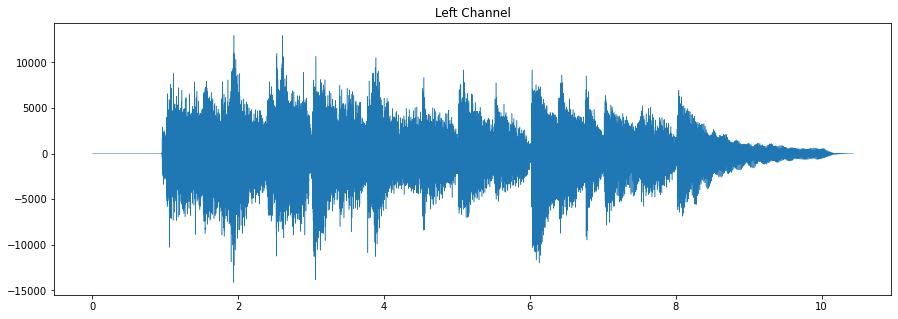

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Right Channel')
plt.xlabel('time')
plt.plot(time, right, linewidth = 0.5)

plt.figure(figsize=(15,5))
plt.title('Left Channel')
plt.plot(time, left, linewidth = 0.5)

## Анализ стерео и моно звука, преобразование стерео в моно

Вывод 10 сек звука пианино в стерео:

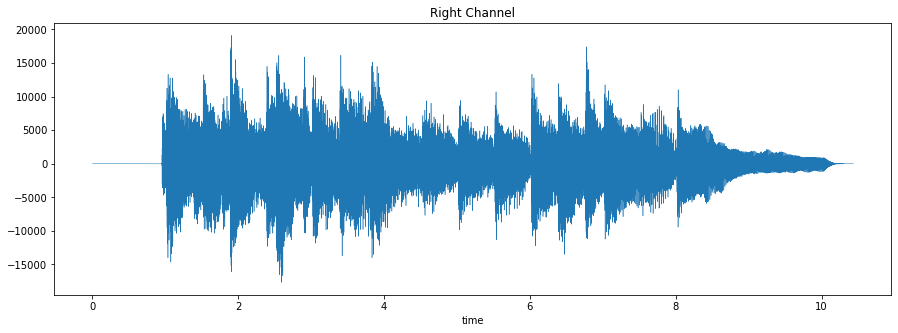

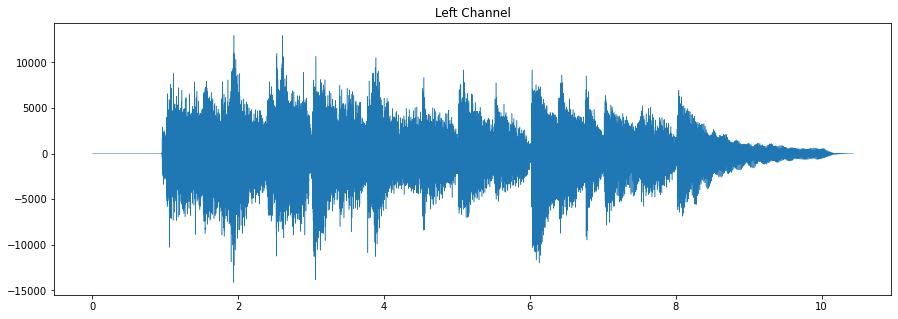

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Right Channel')
plt.xlabel('time')
plt.plot(time, right, linewidth = 0.5)

plt.figure(figsize=(15,5))
plt.title('Left Channel')
plt.plot(time, left, linewidth = 0.5)

Чтение того же файла, конвертированного в моно:

In [ ]:
fp_mono = 'sounds/fortepiano_1_mono.wav'
fq_mono, data_mono = read(fp_mono)
data_mono.shape

(460271,)

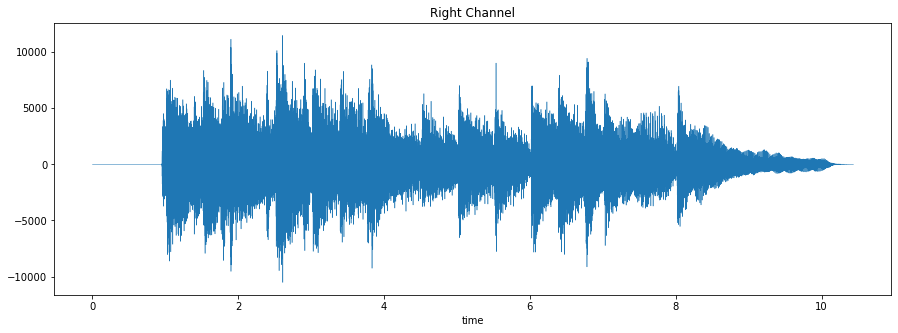

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Right Channel')
plt.xlabel('time')
plt.plot(time, data_mono, linewidth = 0.5)

Сравнение двух стерео каналов и одного моно:

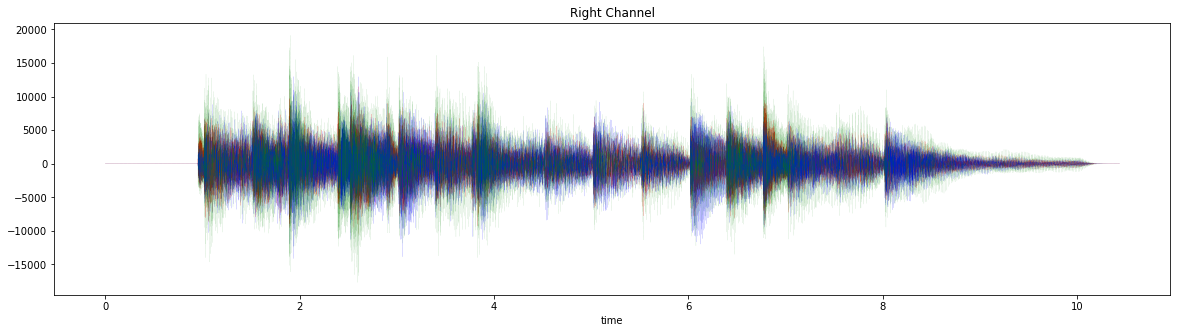

In [ ]:
plt.figure(figsize=(20,5))
plt.title('Right Channel')
plt.xlabel('time')
plt.plot(time, data_mono, linestyle='-', color = 'red', linewidth = 0.1)
plt.plot(time, left,linestyle='-.', color = 'blue', linewidth = 0.1)
plt.plot(time, right, linestyle=':', color = 'green', linewidth = 0.1)

**Попробуем создать моно звук из двух стерео, на основе предположений**

Поиск среднего значения между двумя стерео каналами:

In [ ]:
mono = (left+right)/2
comparison = mono == data_mono
np.count_nonzero(comparison == False)


209070

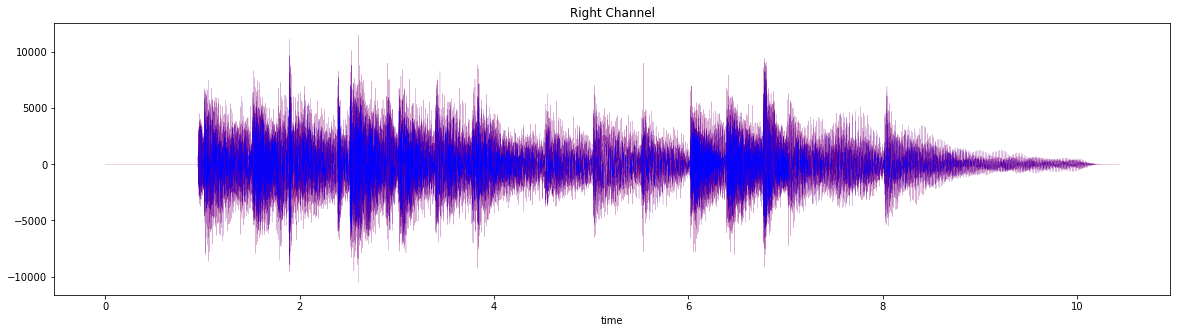

In [ ]:
plt.figure(figsize=(20,5))
plt.title('Right Channel')
plt.xlabel('time')
plt.plot(time, data_mono, linestyle='-', color = 'red', linewidth = 0.1)
plt.plot(time, mono,linestyle='-.', color = 'blue', linewidth = 0.1)


Способ не подходит (?), проверю позже при выводе звука

Способ суммирования сигналов:

Вычетание одного сигнала из другого (инвертирование фазы одного, затем добавление к другому):

**Конвертирование стерео в моно с помощью библиотеки torch и torchaudio:**

In [ ]:
import torch
import torchaudio

In [ ]:
data, sr = torchaudio.load('sounds/fortepiano_1.wav')
mono = torch.mean(data, dim=0, keepdim=True)

RuntimeError: Couldn't find appropriate backend to handle uri sounds/fortepiano_1.wav and format None.

In [ ]:
def stereo_to_mono_convertor(signal):
    # If there is more than 1 channel in your audio
    if signal.shape[0] > 1:
        # Do a mean of all channels and keep it in one channel
        signal = torch.mean(signal, dim=0, keepdim=True)
    return signal

# Load audio as tensor
waveform, sr = torchaudio.load('sounds/fortepiano_1.wav')
# Convert it to mono channel
waveform = stereo_to_mono_convertor(waveform)

RuntimeError: Couldn't find appropriate backend to handle uri sounds/fortepiano_1.wav and format None.

***Продолжу выяснение конвертирования стерео в моно позже***

## Построение спектра

In [ ]:
from scipy.fft import fft, fftfreq

fp = 'sounds/fortepiano_1_mono.wav'
fs, data = read(fp)
time = np.arange(right.size)*(1/fs)

In [ ]:
y = fft(data)
x = fftfreq(len(data), 1 / fs)

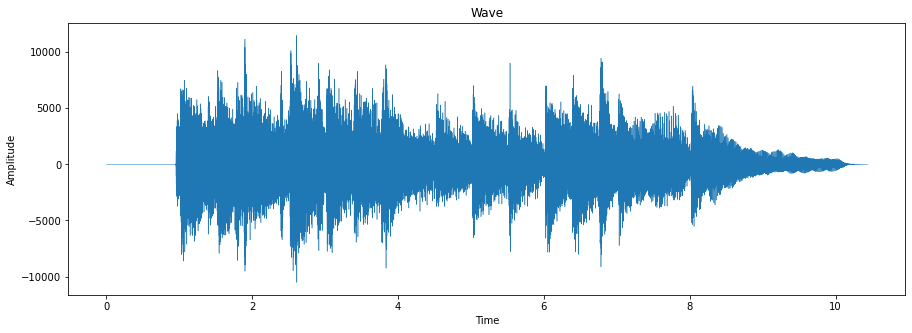

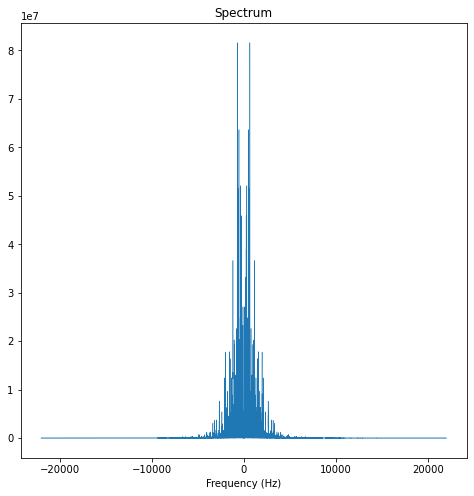

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Wave')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.plot(time, data, linewidth = 0.5)

plt.figure(figsize=(8, 8))
plt.title('Spectrum')
plt.xlabel('Frequency (Hz)')
plt.plot(x, np.abs(y), linewidth = 0.5)
